#**Import Library**

In [427]:
# Library untuk mengakses file dan folder
import os
import kagglehub

# Library untuk pengolahan data
import pandas as pd
import numpy as np

# Library untuk visualisasi data
import matplotlib.pyplot as plt
import plotly.express as px

# Library untuk A/B Testing
from scipy import stats

# Library untuk mengakses Google Drive
from google.colab import drive

#**Data Wrangling**

##Data Gathering

In [428]:
# Mengunduh dataset dari Kaggle
path = kagglehub.dataset_download("rakafal/harga-pertanian-jawa-timur")
print("Path dataset:", path)

# Membaca file CSV utama
files = os.listdir(path)
csv_files = [file for file in files if file.endswith("harga_pertanian.csv")]

data_kaggle = pd.read_csv(os.path.join(path, csv_files[0]))

display(data_kaggle.head())

Using Colab cache for faster access to the 'harga-pertanian-jawa-timur' dataset.
Path dataset: /kaggle/input/harga-pertanian-jawa-timur


,id,id_index,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,periode_update,kategori,jumlah,satuan,tahun
0,1,11,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2020-01,BERAS MEDIUM,8500,RP/KG,2020
1,1,21,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2020-01,BERAS PREMIUM,10500,RP/KG,2020
2,1,31,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2020-01,GABAH KERING GILING,5500,RP/KG,2020
3,1,41,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2020-01,GABAH KERING PANEN,0,RP/KG,2020
4,1,51,35,JAWA TIMUR,3501,KABUPATEN PACITAN,2020-01,JAGUNG PIPIL KERING,4200,RP/KG,2020


In [429]:
# Menghubungkan Google Drive
drive.mount('/content/drive')

# Path data BPS di Google Drive
file_path_bps = '/content/drive/MyDrive/data_raw_bps.csv'

# Membaca data BPS
data_bps = pd.read_csv(file_path_bps)

# Menampilkan 5 data pertama
display(data_bps.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,nama_kabupaten_kota,periode_update,kategori,jumlah
0,KABUPATEN BANGKALAN,2025-08-01,BERAS MEDIUM,11500
1,KABUPATEN BANGKALAN,2025-09-01,BERAS MEDIUM,12000
2,KABUPATEN BANGKALAN,2025-10-01,BERAS MEDIUM,12500
3,KABUPATEN BANGKALAN,2025-11-01,BERAS MEDIUM,12400
4,KABUPATEN BANGKALAN,2025-12-01,BERAS MEDIUM,12400


In [430]:
# Memilih kolom utama
kolom_utama = [
    'nama_kabupaten_kota',
    'periode_update',
    'kategori',
    'jumlah'
]

data_kaggle = data_kaggle[kolom_utama].copy()
data_bps = data_bps[kolom_utama].copy()

# Menambahkan sumber data
data_kaggle['sumber'] = 'kaggle'
data_bps['sumber'] = 'bps'

print("Kolom Kaggle:", data_kaggle.columns.tolist())
print("Kolom BPS:", data_bps.columns.tolist())

Kolom Kaggle: ['nama_kabupaten_kota', 'periode_update', 'kategori', 'jumlah', 'sumber']
Kolom BPS: ['nama_kabupaten_kota', 'periode_update', 'kategori', 'jumlah', 'sumber']


In [431]:
# Menggabungkan data Kaggle dan BPS
data_gabungan = pd.concat(
    [data_kaggle, data_bps],
    ignore_index=True
)

print("Jumlah data Kaggle:", data_kaggle.shape[0])
print("Jumlah data BPS:", data_bps.shape[0])
print("Jumlah data gabungan:", data_gabungan.shape[0])

display(data_gabungan.head())
display(data_gabungan.tail())

Jumlah data Kaggle: 15276
Jumlah data BPS: 1520
Jumlah data gabungan: 16796


,nama_kabupaten_kota,periode_update,kategori,jumlah,sumber
0,KABUPATEN PACITAN,2020-01,BERAS MEDIUM,8500,kaggle
1,KABUPATEN PACITAN,2020-01,BERAS PREMIUM,10500,kaggle
2,KABUPATEN PACITAN,2020-01,GABAH KERING GILING,5500,kaggle
3,KABUPATEN PACITAN,2020-01,GABAH KERING PANEN,0,kaggle
4,KABUPATEN PACITAN,2020-01,JAGUNG PIPIL KERING,4200,kaggle


,nama_kabupaten_kota,periode_update,kategori,jumlah,sumber
16791,KOTA SURABAYA,2026-01-01,KEDELAI,13333,bps
16792,KOTA SURABAYA,2026-02-01,KEDELAI,13333,bps
16793,KOTA SURABAYA,2026-03-01,KEDELAI,14000,bps
16794,KOTA SURABAYA,2026-04-01,KEDELAI,14500,bps
16795,KOTA SURABAYA,2026-05-01,KEDELAI,14000,bps


**Insight :**
- Dataset berasal dari dua sumber, yaitu Kaggle dan BPS.
- Data Kaggle digunakan sebagai data historis utama harga pertanian Jawa Timur.
- Data BPS digunakan sebagai data tambahan untuk melengkapi periode terbaru.
- Kedua dataset disamakan ke dalam kolom utama yang sama sebelum digabung.
- Kolom `sumber` ditambahkan untuk membedakan asal data pada proses selanjutnya.
- Hasil akhir tahap gathering adalah `data_gabungan`, yang akan digunakan pada tahap assessing dan cleaning.

##Data Assessing

In [432]:
# Membuat salinan data untuk assessing
data_assessing = data_gabungan.copy()

print("Jumlah baris:", data_assessing.shape[0])
print("Jumlah kolom:", data_assessing.shape[1])
print("Jumlah duplikat penuh:", data_assessing.duplicated().sum())

data_assessing.info()
display(data_assessing.head())

Jumlah baris: 16796
Jumlah kolom: 5
Jumlah duplikat penuh: 478
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16796 entries, 0 to 16795
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   nama_kabupaten_kota  16796 non-null  object
 1   periode_update       16796 non-null  object
 2   kategori             16796 non-null  object
 3   jumlah               16796 non-null  int64 
 4   sumber               16796 non-null  object
dtypes: int64(1), object(4)
memory usage: 656.2+ KB


,nama_kabupaten_kota,periode_update,kategori,jumlah,sumber
0,KABUPATEN PACITAN,2020-01,BERAS MEDIUM,8500,kaggle
1,KABUPATEN PACITAN,2020-01,BERAS PREMIUM,10500,kaggle
2,KABUPATEN PACITAN,2020-01,GABAH KERING GILING,5500,kaggle
3,KABUPATEN PACITAN,2020-01,GABAH KERING PANEN,0,kaggle
4,KABUPATEN PACITAN,2020-01,JAGUNG PIPIL KERING,4200,kaggle


In [433]:
# Mengecek tipe data, missing value, dan jumlah nilai unik
cek_kolom = pd.DataFrame({
    'tipe_data': data_assessing.dtypes.astype(str),
    'missing_value': data_assessing.isna().sum(),
    'jumlah_unik': data_assessing.nunique()
})

display(cek_kolom)

,tipe_data,missing_value,jumlah_unik
nama_kabupaten_kota,object,0,38
periode_update,object,0,77
kategori,object,0,6
jumlah,int64,0,4368
sumber,object,0,2


In [434]:
# Mengecek cakupan periode data
periode_cek = pd.to_datetime(
    data_assessing['periode_update'].astype(str).str.strip(),
    format='mixed',
    errors='coerce'
)

print("Periode awal:", periode_cek.min())
print("Periode akhir:", periode_cek.max())
print("Tanggal gagal dikonversi:", periode_cek.isna().sum())

# Mengecek jumlah data berdasarkan sumber
jumlah_per_sumber = data_assessing['sumber'].value_counts().reset_index()
jumlah_per_sumber.columns = ['sumber', 'jumlah_data']

display(jumlah_per_sumber)

Periode awal: 2020-01-01 00:00:00
Periode akhir: 2026-05-01 00:00:00
Tanggal gagal dikonversi: 0


,sumber,jumlah_data
0,kaggle,15276
1,bps,1520


In [435]:
# Mengecek kategori
print("Jumlah kategori unik:", data_assessing['kategori'].nunique())

jumlah_per_kategori = data_assessing['kategori'].value_counts().reset_index()
jumlah_per_kategori.columns = ['kategori', 'jumlah_data']

display(jumlah_per_kategori)

Jumlah kategori unik: 6


,kategori,jumlah_data
0,BERAS MEDIUM,2926
1,BERAS PREMIUM,2926
2,KEDELAI,2926
3,JAGUNG PIPIL KERING,2926
4,GABAH KERING PANEN,2546
5,GABAH KERING GILING,2546


In [436]:
# Mengecek jumlah wilayah
print("Jumlah wilayah unik:", data_assessing['nama_kabupaten_kota'].nunique())

jumlah_per_wilayah = (
    data_assessing['nama_kabupaten_kota']
    .value_counts()
    .sort_index()
    .reset_index()
)

jumlah_per_wilayah.columns = ['nama_kabupaten_kota', 'jumlah_data']

display(jumlah_per_wilayah)

Jumlah wilayah unik: 38


,nama_kabupaten_kota,jumlah_data
0,KABUPATEN BANGKALAN,442
1,KABUPATEN BANYUWANGI,442
2,KABUPATEN BLITAR,40
3,KABUPATEN BOJONEGORO,442
4,KABUPATEN BONDOWOSO,442
5,KABUPATEN GRESIK,442
6,KABUPATEN JEMBER,442
7,KABUPATEN JOMBANG,442
8,KABUPATEN KEDIRI,40
9,KABUPATEN LAMONGAN,442


In [437]:
# Mengecek nilai 0 pada kolom jumlah
jumlah_nol = (data_assessing['jumlah'] == 0).sum()
persentase_nol = round(jumlah_nol / len(data_assessing) * 100, 2)

print("Jumlah data bernilai 0:", jumlah_nol)
print("Persentase nilai 0:", persentase_nol, "%")

data_nol = data_assessing[data_assessing['jumlah'] == 0].copy()

jumlah_nol_per_kategori = data_nol['kategori'].value_counts().reset_index()
jumlah_nol_per_kategori.columns = ['kategori', 'jumlah_data_nol']

display(jumlah_nol_per_kategori)

Jumlah data bernilai 0: 5723
Persentase nilai 0: 34.07 %


,kategori,jumlah_data_nol
0,KEDELAI,2143
1,GABAH KERING PANEN,822
2,BERAS PREMIUM,735
3,GABAH KERING GILING,708
4,JAGUNG PIPIL KERING,699
5,BERAS MEDIUM,616


In [438]:
# Mengecek wilayah yang memiliki pasangan Kota dan Kabupaten
data_wilayah_cek = data_assessing.copy()

data_wilayah_cek['wilayah_bersih'] = (
    data_wilayah_cek['nama_kabupaten_kota']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.title()
)

nama_wilayah_dicek = [
    'Blitar',
    'Kediri',
    'Malang',
    'Madiun',
    'Mojokerto',
    'Pasuruan',
    'Probolinggo'
]

wilayah_terkait = []

for nama in nama_wilayah_dicek:
    wilayah_terkait.extend([
        'Kota ' + nama,
        'Kabupaten ' + nama
    ])

jumlah_wilayah_terkait = (
    data_wilayah_cek[
        data_wilayah_cek['wilayah_bersih'].isin(wilayah_terkait)
    ]['wilayah_bersih']
    .value_counts()
    .sort_index()
    .reset_index()
)

jumlah_wilayah_terkait.columns = ['nama_wilayah', 'jumlah_data']

display(jumlah_wilayah_terkait)

,nama_wilayah,jumlah_data
0,Kabupaten Blitar,40
1,Kabupaten Kediri,40
2,Kabupaten Madiun,40
3,Kabupaten Malang,40
4,Kabupaten Mojokerto,40
5,Kabupaten Pasuruan,40
6,Kabupaten Probolinggo,40
7,Kota Blitar,844
8,Kota Kediri,844
9,Kota Madiun,844


**Insight :**
- Dataset gabungan sudah memiliki kolom utama yang dibutuhkan, yaitu `nama_kabupaten_kota`, `periode_update`, `kategori`, `jumlah`, dan `sumber`.
- Data berasal dari dua sumber, yaitu Kaggle sebagai data historis dan BPS sebagai data tambahan periode terbaru.
- Format `periode_update` perlu diseragamkan pada tahap cleaning agar seluruh periode berada dalam format tanggal bulanan yang sama.
- Penulisan `nama_kabupaten_kota` dan `kategori` perlu dirapikan agar tidak terjadi perbedaan format huruf atau spasi.
- Masih terdapat nilai 0 pada kolom `jumlah`, sehingga perlu ditangani pada tahap cleaning.
- Nilai 0 tidak dihapus langsung karena data berbentuk time series bulanan dan penghapusan baris dapat merusak urutan periode.
- Beberapa wilayah Kota/Kabupaten perlu dicek karena terdapat nama kota yang memiliki pasangan kabupaten dengan nama sama.

## Data Cleaning

In [439]:
# Salin data untuk cleaning
data_clean = data_gabungan.copy()

# Rapikan tanggal
data_clean['periode_update'] = pd.to_datetime(
    data_clean['periode_update'].astype(str).str.strip(),
    format='mixed',
    errors='coerce'
)

data_clean['periode_update'] = data_clean['periode_update'].dt.to_period('M').dt.to_timestamp()

# Rapikan wilayah
data_clean['nama_kabupaten_kota'] = (
    data_clean['nama_kabupaten_kota']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.title()
)

# Rapikan kategori
data_clean['kategori'] = (
    data_clean['kategori']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.title()
)

# Pastikan harga numerik
data_clean['jumlah'] = pd.to_numeric(data_clean['jumlah'], errors='coerce')

print("Jumlah data:", data_clean.shape[0])
print("Tanggal gagal:", data_clean['periode_update'].isna().sum())
print("Harga gagal:", data_clean['jumlah'].isna().sum())
print("Jumlah kategori:", data_clean['kategori'].nunique())

display(data_clean.head())

Jumlah data: 16796
Tanggal gagal: 0
Harga gagal: 0
Jumlah kategori: 6


,nama_kabupaten_kota,periode_update,kategori,jumlah,sumber
0,Kabupaten Pacitan,2020-01-01,Beras Medium,8500,kaggle
1,Kabupaten Pacitan,2020-01-01,Beras Premium,10500,kaggle
2,Kabupaten Pacitan,2020-01-01,Gabah Kering Giling,5500,kaggle
3,Kabupaten Pacitan,2020-01-01,Gabah Kering Panen,0,kaggle
4,Kabupaten Pacitan,2020-01-01,Jagung Pipil Kering,4200,kaggle


In [440]:
# Wilayah kota yang perlu dipisah dari data Kaggle
wilayah_kota_double = [
    'Kota Blitar',
    'Kota Kediri',
    'Kota Malang',
    'Kota Madiun',
    'Kota Mojokerto',
    'Kota Pasuruan',
    'Kota Probolinggo'
]

# Urutkan data dulu
data_clean = data_clean.sort_values(
    by=['nama_kabupaten_kota', 'periode_update', 'kategori', 'jumlah']
).copy()

# Buat mask setelah data diurutkan
mask_kota_double = (
    (data_clean['sumber'] == 'kaggle') &
    (data_clean['nama_kabupaten_kota'].isin(wilayah_kota_double))
)

# Buat urutan hanya untuk wilayah kota double dari Kaggle
data_clean['_urutan_double'] = np.nan

data_clean.loc[mask_kota_double, '_urutan_double'] = (
    data_clean.loc[mask_kota_double]
    .groupby(['nama_kabupaten_kota', 'periode_update', 'kategori'])
    .cumcount()
)

# Baris pertama jadi Kabupaten, baris kedua tetap Kota
kondisi_jadi_kabupaten = (
    mask_kota_double &
    (data_clean['_urutan_double'] == 0)
)

data_clean.loc[kondisi_jadi_kabupaten, 'nama_kabupaten_kota'] = (
    data_clean.loc[kondisi_jadi_kabupaten, 'nama_kabupaten_kota']
    .str.replace('Kota ', 'Kabupaten ', regex=False)
)

data_clean = data_clean.drop(columns=['_urutan_double'])

display(
    data_clean[
        data_clean['nama_kabupaten_kota'].str.contains(
            'Blitar|Kediri|Malang|Madiun|Mojokerto|Pasuruan|Probolinggo',
            case=False,
            na=False
        )
    ]['nama_kabupaten_kota']
    .value_counts()
    .sort_index()
)

,count
nama_kabupaten_kota,
Kabupaten Blitar,442
Kabupaten Kediri,442
Kabupaten Madiun,442
Kabupaten Malang,442
Kabupaten Mojokerto,442
Kabupaten Pasuruan,442
Kabupaten Probolinggo,442
Kota Blitar,442
Kota Kediri,442


In [441]:
# Hapus kategori gabah
kategori_drop = [
    'Gabah Kering Giling',
    'Gabah Kering Panen'
]

jumlah_sebelum = data_clean.shape[0]

data_clean = data_clean[
    ~data_clean['kategori'].isin(kategori_drop)
].copy()

jumlah_sesudah = data_clean.shape[0]

print("Data sebelum:", jumlah_sebelum)
print("Data sesudah:", jumlah_sesudah)
print("Data dihapus:", jumlah_sebelum - jumlah_sesudah)

kategori_count = data_clean['kategori'].value_counts().reset_index()
kategori_count.columns = ['kategori', 'jumlah_data']

display(kategori_count)

Data sebelum: 16796
Data sesudah: 11704
Data dihapus: 5092


,kategori,jumlah_data
0,Beras Medium,2926
1,Beras Premium,2926
2,Jagung Pipil Kering,2926
3,Kedelai,2926


In [442]:
# Ubah 0 menjadi NaN
jumlah_0_awal = (data_clean['jumlah'] == 0).sum()

data_clean['jumlah'] = data_clean['jumlah'].replace(0, np.nan)

print("Nilai 0 diubah:", jumlah_0_awal)

# Urutkan data
data_clean = data_clean.sort_values(
    by=['nama_kabupaten_kota', 'kategori', 'periode_update']
).copy()

# Interpolasi per wilayah dan kategori
data_clean['jumlah'] = (
    data_clean
    .groupby(['nama_kabupaten_kota', 'kategori'])['jumlah']
    .transform(lambda x: x.interpolate(method='linear'))
)

# Isi sisa NaN awal/akhir
data_clean['jumlah'] = (
    data_clean
    .groupby(['nama_kabupaten_kota', 'kategori'])['jumlah']
    .transform(lambda x: x.ffill().bfill())
)

# Cadangan median kategori
data_clean['jumlah'] = (
    data_clean
    .groupby('kategori')['jumlah']
    .transform(lambda x: x.fillna(x.median()))
)

data_clean['jumlah'] = data_clean['jumlah'].fillna(data_clean['jumlah'].median())

print("Sisa missing:", data_clean['jumlah'].isna().sum())
print("Sisa nilai 0:", (data_clean['jumlah'] == 0).sum())

Nilai 0 diubah: 4193
Sisa missing: 0
Sisa nilai 0: 0


In [443]:
# Ambil kolom final
data_clean = data_clean[
    ['nama_kabupaten_kota', 'periode_update', 'kategori', 'jumlah']
].copy()

# Urutkan data akhir
data_clean = data_clean.sort_values(
    by=['nama_kabupaten_kota', 'kategori', 'periode_update']
).reset_index(drop=True)

key_cols = ['nama_kabupaten_kota', 'periode_update', 'kategori']

print("Jumlah data akhir:", data_clean.shape[0])
print("Jumlah kolom akhir:", data_clean.shape[1])
print("Missing value:", data_clean.isna().sum().sum())
print("Nilai 0:", (data_clean['jumlah'] == 0).sum())
print("Duplikat key:", data_clean.duplicated(subset=key_cols).sum())
print("Jumlah wilayah:", data_clean['nama_kabupaten_kota'].nunique())
print("Jumlah kategori:", data_clean['kategori'].nunique())
print("Periode awal:", data_clean['periode_update'].min())
print("Periode akhir:", data_clean['periode_update'].max())

display(data_clean.head())

Jumlah data akhir: 11704
Jumlah kolom akhir: 4
Missing value: 0
Nilai 0: 0
Duplikat key: 0
Jumlah wilayah: 38
Jumlah kategori: 4
Periode awal: 2020-01-01 00:00:00
Periode akhir: 2026-05-01 00:00:00


,nama_kabupaten_kota,periode_update,kategori,jumlah
0,Kabupaten Bangkalan,2020-01-01,Beras Medium,8869.0
1,Kabupaten Bangkalan,2020-02-01,Beras Medium,8375.0
2,Kabupaten Bangkalan,2020-03-01,Beras Medium,8275.0
3,Kabupaten Bangkalan,2020-04-01,Beras Medium,8000.0
4,Kabupaten Bangkalan,2020-05-01,Beras Medium,8350.0


**Insight :**
- Kolom `periode_update` telah diseragamkan ke format tanggal bulanan agar data Kaggle dan BPS memiliki struktur waktu yang konsisten.
- Penulisan `nama_kabupaten_kota` dan `kategori` telah dirapikan agar format wilayah dan komoditas menjadi seragam.
- Data wilayah kota yang pada sumber Kaggle memuat pasangan kota dan kabupaten telah dipisahkan berdasarkan asumsi urutan kemunculan data.
- Pemisahan wilayah dilakukan agar data kabupaten yang sebelumnya tergabung dalam nama kota tetap dapat digunakan dan tidak terhapus.
- Kategori Gabah Kering Giling dan Gabah Kering Panen dihapus karena tidak digunakan dalam fokus analisis lanjutan.
- Nilai 0 pada kolom `jumlah` diperlakukan sebagai missing value terselubung karena tidak merepresentasikan harga aktual.
- Nilai kosong pada kolom `jumlah` ditangani menggunakan interpolasi berdasarkan urutan waktu pada setiap kombinasi wilayah dan kategori.
- Dataset hasil cleaning sudah memiliki format yang lebih konsisten dan siap digunakan untuk tahap analisis selanjutnya.

#**Feature Engineering**

In [444]:
# Membuat salinan data untuk feature engineering
data_final = data_clean.copy()

# Membuat identitas unik untuk setiap deret waktu
data_final['series_id'] = (
    data_final['nama_kabupaten_kota'].astype(str)
    + ' | ' +
    data_final['kategori'].astype(str)
)

# Menyusun kolom final
data_final = data_final[
    ['series_id', 'nama_kabupaten_kota', 'periode_update', 'kategori', 'jumlah']
].copy()

# Mengurutkan data final
data_final = data_final.sort_values(
    by=['series_id', 'periode_update']
).reset_index(drop=True)

display(data_final.head())

,series_id,nama_kabupaten_kota,periode_update,kategori,jumlah
0,Kabupaten Bangkalan | Beras Medium,Kabupaten Bangkalan,2020-01-01,Beras Medium,8869.0
1,Kabupaten Bangkalan | Beras Medium,Kabupaten Bangkalan,2020-02-01,Beras Medium,8375.0
2,Kabupaten Bangkalan | Beras Medium,Kabupaten Bangkalan,2020-03-01,Beras Medium,8275.0
3,Kabupaten Bangkalan | Beras Medium,Kabupaten Bangkalan,2020-04-01,Beras Medium,8000.0
4,Kabupaten Bangkalan | Beras Medium,Kabupaten Bangkalan,2020-05-01,Beras Medium,8350.0


In [445]:
print("Jumlah data:", data_final.shape[0])
print("Jumlah wilayah:", data_final['nama_kabupaten_kota'].nunique())
print("Jumlah kategori:", data_final['kategori'].nunique())
print("Jumlah series:", data_final['series_id'].nunique())
print("Periode awal:", data_final['periode_update'].min())
print("Periode akhir:", data_final['periode_update'].max())
print("Missing value:", data_final.isna().sum().sum())

Jumlah data: 11704
Jumlah wilayah: 38
Jumlah kategori: 4
Jumlah series: 152
Periode awal: 2020-01-01 00:00:00
Periode akhir: 2026-05-01 00:00:00
Missing value: 0


**Insight :**
- Fitur `series_id` dibuat untuk membedakan setiap deret waktu berdasarkan kombinasi wilayah dan komoditas.
- Satu `series_id` merepresentasikan satu data time series, misalnya Kabupaten Bangkalan untuk Beras Medium.
- Fitur ini membantu proses modeling karena data dapat dipisahkan berdasarkan wilayah dan komoditas.
- Dataset final sudah siap digunakan untuk dashboard, API, dan pengembangan model forecasting.

#**Exploratory Data Analysis (EDA)**

In [446]:
# Salin data clean untuk analisis
data_analisis = data_clean.copy()

# Tambahkan kolom waktu
data_analisis['tahun'] = data_analisis['periode_update'].dt.year
data_analisis['bulan'] = data_analisis['periode_update'].dt.month
data_analisis['tahun_bulan'] = data_analisis['periode_update'].dt.to_period('M').astype(str)

print("Jumlah data:", data_analisis.shape[0])
print("Jumlah kolom:", data_analisis.shape[1])
print("Periode awal:", data_analisis['periode_update'].min())
print("Periode akhir:", data_analisis['periode_update'].max())
print("Jumlah wilayah:", data_analisis['nama_kabupaten_kota'].nunique())
print("Jumlah kategori:", data_analisis['kategori'].nunique())

display(data_analisis.head())

Jumlah data: 11704
Jumlah kolom: 7
Periode awal: 2020-01-01 00:00:00
Periode akhir: 2026-05-01 00:00:00
Jumlah wilayah: 38
Jumlah kategori: 4


,nama_kabupaten_kota,periode_update,kategori,jumlah,tahun,bulan,tahun_bulan
0,Kabupaten Bangkalan,2020-01-01,Beras Medium,8869.0,2020,1,2020-01
1,Kabupaten Bangkalan,2020-02-01,Beras Medium,8375.0,2020,2,2020-02
2,Kabupaten Bangkalan,2020-03-01,Beras Medium,8275.0,2020,3,2020-03
3,Kabupaten Bangkalan,2020-04-01,Beras Medium,8000.0,2020,4,2020-04
4,Kabupaten Bangkalan,2020-05-01,Beras Medium,8350.0,2020,5,2020-05


In [447]:
# Mengecek jumlah data pada setiap kategori
data_per_kategori = (
    data_analisis['kategori']
    .value_counts()
    .reset_index()
)

data_per_kategori.columns = ['kategori', 'jumlah_data']

display(data_per_kategori)

,kategori,jumlah_data
0,Beras Medium,2926
1,Beras Premium,2926
2,Jagung Pipil Kering,2926
3,Kedelai,2926


In [448]:
# Mengecek jumlah data pada setiap wilayah
data_per_wilayah = (
    data_analisis['nama_kabupaten_kota']
    .value_counts()
    .sort_index()
    .reset_index()
)

data_per_wilayah.columns = ['nama_kabupaten_kota', 'jumlah_data']

display(data_per_wilayah)

,nama_kabupaten_kota,jumlah_data
0,Kabupaten Bangkalan,308
1,Kabupaten Banyuwangi,308
2,Kabupaten Blitar,308
3,Kabupaten Bojonegoro,308
4,Kabupaten Bondowoso,308
5,Kabupaten Gresik,308
6,Kabupaten Jember,308
7,Kabupaten Jombang,308
8,Kabupaten Kediri,308
9,Kabupaten Lamongan,308


In [449]:
# Mengecek statistik deskriptif kolom jumlah
statistik_harga = data_analisis['jumlah'].describe().reset_index()
statistik_harga.columns = ['statistik', 'nilai']

display(statistik_harga)

,statistik,nilai
0,count,11704.000000
1,mean,9729.964286
2,std,3293.250225
3,min,3000.000000
4,25%,7496.875000
5,50%,9868.177419
6,75%,12435.750000
7,max,19333.000000


In [450]:
# Melihat pola rata-rata harga per bulan
tren_bulanan = (
    data_analisis
    .groupby('tahun_bulan')
    .agg(
        jumlah_data=('jumlah', 'count'),
        rata_rata_harga=('jumlah', 'mean'),
        median_harga=('jumlah', 'median'),
        harga_minimum=('jumlah', 'min'),
        harga_maksimum=('jumlah', 'max')
    )
    .reset_index()
)

display(tren_bulanan)

,tahun_bulan,jumlah_data,rata_rata_harga,median_harga,harga_minimum,harga_maksimum
0,2020-01,152,8189.447368,8675.5,3538.0,17300.0
1,2020-02,152,8137.398272,8581.5,3700.0,17216.0
2,2020-03,152,8224.134263,8623.5,3700.0,17216.0
3,2020-04,152,8164.455651,8623.5,3450.0,17216.0
4,2020-05,152,8129.314355,8665.0,3038.0,17216.0
...,...,...,...,...,...,...
72,2026-01,152,11878.697368,12833.0,5750.0,17250.0
73,2026-02,152,11879.796053,12800.0,5750.0,17250.0
74,2026-03,152,11942.967105,12875.0,5750.0,19333.0
75,2026-04,152,11882.078947,13000.0,5750.0,17333.0


In [451]:
# Mengecek kelengkapan dan kelayakan komoditas untuk dianalisis
kesiapan_kategori = (
    data_analisis
    .groupby('kategori')
    .agg(
        jumlah_data=('jumlah', 'count'),
        jumlah_bulan=('tahun_bulan', 'nunique'),
        jumlah_wilayah=('nama_kabupaten_kota', 'nunique'),
        rata_rata_harga=('jumlah', 'mean'),
        standar_deviasi=('jumlah', 'std')
    )
    .sort_values(
        ['jumlah_bulan', 'jumlah_data', 'jumlah_wilayah'],
        ascending=False
    )
    .reset_index()
)

# Mengambil kategori yang memiliki kelengkapan data terbaik
kategori_layak_analisis = kesiapan_kategori[
    (kesiapan_kategori['jumlah_data'] == kesiapan_kategori['jumlah_data'].max()) &
    (kesiapan_kategori['jumlah_bulan'] == kesiapan_kategori['jumlah_bulan'].max()) &
    (kesiapan_kategori['jumlah_wilayah'] == kesiapan_kategori['jumlah_wilayah'].max())
].copy()

display(kesiapan_kategori)

print("Jumlah kategori layak dianalisis:", kategori_layak_analisis['kategori'].nunique())
print("Kategori layak dianalisis:", kategori_layak_analisis['kategori'].tolist())

,kategori,jumlah_data,jumlah_bulan,jumlah_wilayah,rata_rata_harga,standar_deviasi
0,Beras Medium,2926,77,38,10687.872010,1808.804260
1,Beras Premium,2926,77,38,12288.284860,2030.162623
2,Jagung Pipil Kering,2926,77,38,5538.651230,1588.590312
3,Kedelai,2926,77,38,10405.049043,2825.245221


Jumlah kategori layak dianalisis: 4
Kategori layak dianalisis: ['Beras Medium', 'Beras Premium', 'Jagung Pipil Kering', 'Kedelai']


**Insight :**
- Dataset hasil cleaning terdiri dari **11.704 data**, **38 wilayah**, dan **4 kategori komoditas**.
- Periode data mencakup **77 bulan**, yaitu dari **Januari 2020 sampai Mei 2026**.
- Setiap kategori memiliki jumlah data yang sama, yaitu **2.926 data**.
- Setiap kategori juga memiliki cakupan yang sama, yaitu **77 bulan** dan **38 wilayah**.
- Setiap wilayah memiliki jumlah data yang sama, yaitu **308 data**.
- Hal ini menunjukkan bahwa data sudah seimbang berdasarkan kategori, wilayah, dan periode.
- Kategori yang dianalisis setelah cleaning adalah **Beras Medium, Beras Premium, Jagung Pipil Kering, dan Kedelai**.
- Berdasarkan rata-rata harga, **Beras Premium** memiliki harga tertinggi, yaitu sekitar **12.288,28**.
- **Jagung Pipil Kering** memiliki rata-rata harga terendah, yaitu sekitar **5.538,65**.
- **Kedelai** memiliki standar deviasi tertinggi, yaitu sekitar **2.825,25**, sehingga menunjukkan variasi harga paling besar dibanding kategori lain.
- Karena seluruh kategori memiliki kelengkapan data yang sama, seluruh komoditas layak dianalisis.
- **Beras Medium** digunakan sebagai komoditas default visualisasi awal, bukan sebagai satu-satunya komoditas yang dianalisis.

#**Data Dictionary**

In [452]:
# Membuat data dictionary untuk dataset final
data_dictionary = pd.DataFrame({
    'nama_kolom': [
        'series_id',
        'nama_kabupaten_kota',
        'periode_update',
        'kategori',
        'jumlah'
    ],
    'tipe_data': [
        str(data_final['series_id'].dtype),
        str(data_final['nama_kabupaten_kota'].dtype),
        str(data_final['periode_update'].dtype),
        str(data_final['kategori'].dtype),
        str(data_final['jumlah'].dtype)
    ],
    'deskripsi': [
        'Identitas unik deret waktu berdasarkan gabungan wilayah dan komoditas.',
        'Nama kabupaten atau kota di Provinsi Jawa Timur.',
        'Periode pencatatan harga dalam format bulanan.',
        'Jenis komoditas pangan yang dipantau.',
        'Harga komoditas dalam rupiah.'
    ],
    'contoh_nilai': [
        data_final['series_id'].iloc[0],
        data_final['nama_kabupaten_kota'].iloc[0],
        data_final['periode_update'].iloc[0],
        data_final['kategori'].iloc[0],
        data_final['jumlah'].iloc[0]
    ]
})

display(data_dictionary)

,nama_kolom,tipe_data,deskripsi,contoh_nilai
0,series_id,object,Identitas unik deret waktu berdasarkan gabunga...,Kabupaten Bangkalan | Beras Medium
1,nama_kabupaten_kota,object,Nama kabupaten atau kota di Provinsi Jawa Timur.,Kabupaten Bangkalan
2,periode_update,datetime64[ns],Periode pencatatan harga dalam format bulanan.,2020-01-01 00:00:00
3,kategori,object,Jenis komoditas pangan yang dipantau.,Beras Medium
4,jumlah,float64,Harga komoditas dalam rupiah.,8869.0


**Insight :**
- Data dictionary dibuat untuk menjelaskan struktur dataset final.
- Setiap kolom pada dataset final sudah memiliki deskripsi, tipe data, dan contoh nilai.
- Kolom `series_id` digunakan untuk membedakan setiap deret waktu berdasarkan wilayah dan komoditas.
- Data dictionary membantu pengguna, tim AI, dan pihak lain memahami isi dataset sebelum digunakan untuk dashboard atau pemodelan.

#**Visualization & Explanatory Analysis**

In [453]:
# Komoditas yang dianalisis pada visualisasi awal
komoditas_pilihan = 'Beras Medium'

# Data komoditas terpilih
data_komoditas = data_analisis[
    data_analisis['kategori'] == komoditas_pilihan
].copy()

data_komoditas = data_komoditas.sort_values(
    by=['nama_kabupaten_kota', 'periode_update']
).reset_index(drop=True)

# Fungsi label pendek
def label_wilayah(nama):
    return (
        nama.replace('Kabupaten ', 'Kab.\n')
            .replace('Kota ', 'Kota\n')
    )

# Label komoditas rapi
label_komoditas = {
    'Beras Medium': 'Beras\nMedium',
    'Beras Premium': 'Beras\nPremium',
    'Jagung Pipil Kering': 'Jagung Pipil\nKering',
    'Kedelai': 'Kedelai'
}

print("Komoditas yang dianalisis:", komoditas_pilihan)

Komoditas yang dianalisis: Beras Medium


###1. What: Komoditas pangan mana yang perlu menjadi prioritas pemantauan harga di SiPangan berdasarkan rata-rata harga dan tingkat fluktuasi harga selama Januari 2020 sampai Mei 2026?

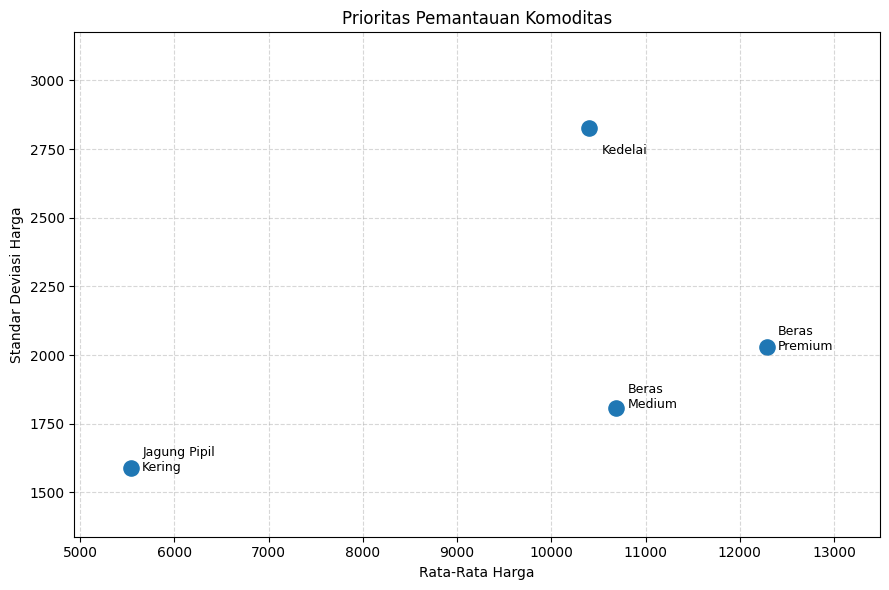

In [454]:
# Menyiapkan data rata-rata dan variasi harga per komoditas
prioritas_komoditas = kesiapan_kategori.copy()

# Label komoditas dibuat lebih rapi
label_komoditas = {
    'Beras Medium': 'Beras\nMedium',
    'Beras Premium': 'Beras\nPremium',
    'Jagung Pipil Kering': 'Jagung Pipil\nKering',
    'Kedelai': 'Kedelai'
}

prioritas_komoditas['label'] = (
    prioritas_komoditas['kategori']
    .map(label_komoditas)
    .fillna(prioritas_komoditas['kategori'])
)

# Membuat scatter plot
plt.figure(figsize=(9, 6))

plt.scatter(
    prioritas_komoditas['rata_rata_harga'],
    prioritas_komoditas['standar_deviasi'],
    s=120
)

# Posisi label manual agar tidak bertabrakan
posisi_label = {
    'Beras Medium': (120, 40),
    'Beras Premium': (120, 30),
    'Jagung Pipil Kering': (120, 30),
    'Kedelai': (130, -80)
}

# Menampilkan label titik
for _, row in prioritas_komoditas.iterrows():
    dx, dy = posisi_label.get(row['kategori'], (100, 30))

    plt.text(
        row['rata_rata_harga'] + dx,
        row['standar_deviasi'] + dy,
        row['label'],
        ha='left',
        va='center',
        fontsize=9
    )

plt.title('Prioritas Pemantauan Komoditas')
plt.xlabel('Rata-Rata Harga')
plt.ylabel('Standar Deviasi Harga')

# Memberi ruang agar label tidak terpotong
plt.xlim(
    prioritas_komoditas['rata_rata_harga'].min() - 600,
    prioritas_komoditas['rata_rata_harga'].max() + 1200
)

plt.ylim(
    prioritas_komoditas['standar_deviasi'].min() - 250,
    prioritas_komoditas['standar_deviasi'].max() + 350
)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Insight :**
- Beras Premium memiliki rata-rata harga paling tinggi, yaitu sekitar **Rp12.288**.
- Kedelai memiliki fluktuasi harga paling besar, dengan standar deviasi sekitar **Rp2.825**.
- Jagung Pipil Kering memiliki rata-rata harga paling rendah, yaitu sekitar **Rp5.539**.
- Beras Medium berada pada level harga sekitar **Rp10.688** dengan fluktuasi lebih rendah dibanding Kedelai dan Beras Premium.
- Komoditas yang perlu perhatian utama adalah **Beras Premium** dari sisi harga tinggi dan **Kedelai** dari sisi fluktuasi harga.
- Seluruh komoditas tetap layak masuk dalam pemantauan SiPangan karena masing-masing memiliki karakteristik harga yang berbeda.

###2. Who: Kelompok wilayah mana yang memiliki harga rata-rata tertinggi untuk komoditas yang dipilih selama Januari 2020 sampai Mei 2026?

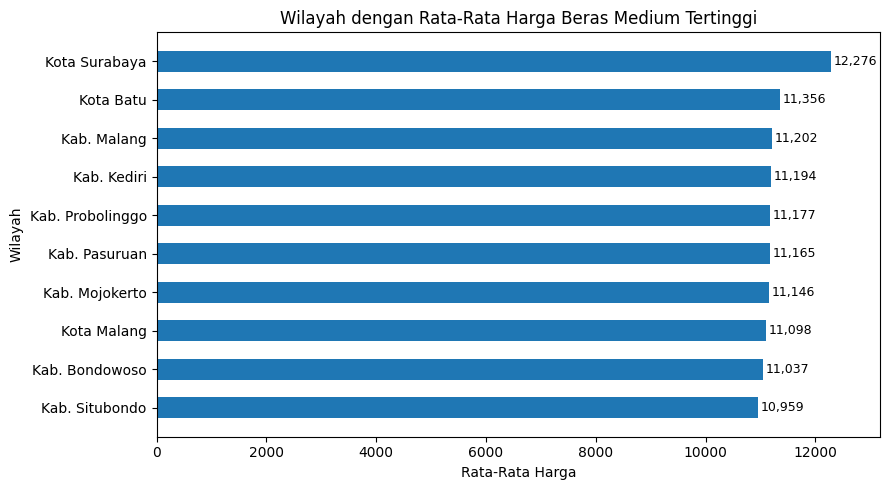

In [455]:
# Menghitung rata-rata harga per wilayah
rata_harga_wilayah = (
    data_komoditas
    .groupby('nama_kabupaten_kota')['jumlah']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

rata_harga_wilayah.columns = ['nama_kabupaten_kota', 'rata_rata_harga']

# Membuat label wilayah lebih pendek
label_wilayah = (
    rata_harga_wilayah['nama_kabupaten_kota']
    .str.replace('Kabupaten ', 'Kab. ', regex=False)
)

# Membuat visualisasi
plt.figure(figsize=(9, 5))

bars = plt.barh(
    label_wilayah,
    rata_harga_wilayah['rata_rata_harga'],
    height=0.55
)

plt.title(f'Wilayah dengan Rata-Rata Harga {komoditas_pilihan} Tertinggi')
plt.xlabel('Rata-Rata Harga')
plt.ylabel('Wilayah')

# Membalik urutan agar tertinggi di atas
plt.gca().invert_yaxis()

# Menampilkan nilai pada bar
for bar in bars:
    plt.text(
        bar.get_width() + 50,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():,.0f}',
        va='center',
        fontsize=9
    )

plt.xlim(0, rata_harga_wilayah['rata_rata_harga'].max() + 900)
plt.tight_layout()
plt.show()

**Insight :**
- Kota Surabaya memiliki rata-rata harga Beras Medium tertinggi, yaitu sekitar **Rp12.276**.
- Kota Batu berada di posisi berikutnya dengan rata-rata harga sekitar **Rp12.099**.
- Kabupaten Malang memiliki rata-rata harga sekitar **Rp11.784**.
- Wilayah lain yang termasuk kelompok harga tinggi adalah Kabupaten Kediri, Kabupaten Probolinggo, Kabupaten Pasuruan, Kota Malang, Kota Pasuruan, Kabupaten Mojokerto, dan Kabupaten Bondowoso.
- Kota Surabaya menjadi wilayah yang perlu diperhatikan karena harga Beras Medium di wilayah tersebut paling tinggi dibanding wilayah lain.

###3. When:  Pada bulan apa komoditas yang dipilih mengalami kenaikan harga terbesar selama Januari 2020 sampai Mei 2026?

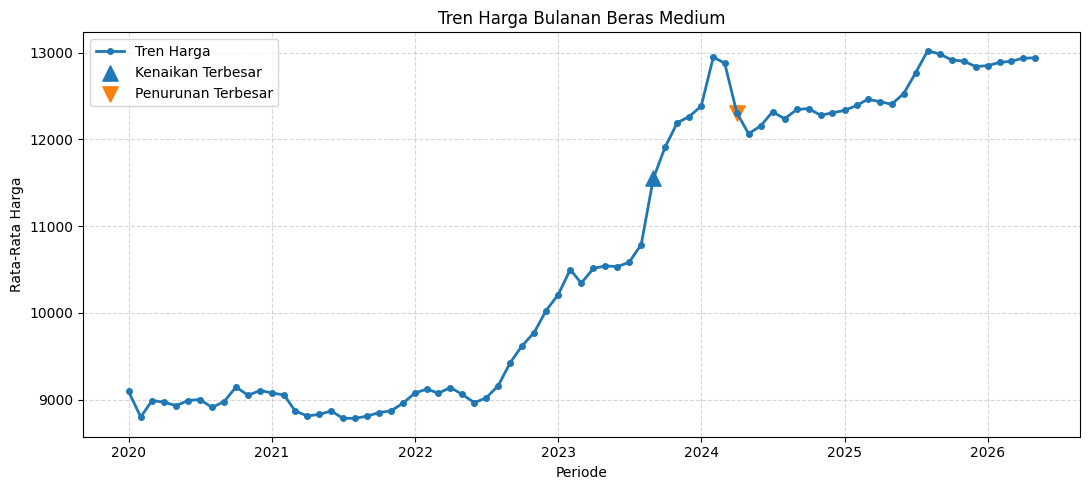

In [456]:
# Menghitung tren harga bulanan
tren_bulanan_komoditas = (
    data_komoditas
    .groupby('periode_update')['jumlah']
    .mean()
    .reset_index()
    .sort_values('periode_update')
)

# Menghitung perubahan harga bulanan
tren_bulanan_komoditas['perubahan_harga'] = tren_bulanan_komoditas['jumlah'].diff()

# Mengambil kenaikan dan penurunan terbesar
data_perubahan = tren_bulanan_komoditas.dropna(subset=['perubahan_harga'])

kenaikan_terbesar = data_perubahan.loc[
    data_perubahan['perubahan_harga'].idxmax()
]

penurunan_terbesar = data_perubahan.loc[
    data_perubahan['perubahan_harga'].idxmin()
]

# Membuat visualisasi tren harga
plt.figure(figsize=(11, 5))

plt.plot(
    tren_bulanan_komoditas['periode_update'],
    tren_bulanan_komoditas['jumlah'],
    marker='o',
    linewidth=2,
    markersize=4,
    label='Tren Harga'
)

# Menandai kenaikan terbesar
plt.scatter(
    kenaikan_terbesar['periode_update'],
    kenaikan_terbesar['jumlah'],
    s=120,
    marker='^',
    label='Kenaikan Terbesar'
)

# Menandai penurunan terbesar
plt.scatter(
    penurunan_terbesar['periode_update'],
    penurunan_terbesar['jumlah'],
    s=120,
    marker='v',
    label='Penurunan Terbesar'
)

plt.title(f'Tren Harga Bulanan {komoditas_pilihan}')
plt.xlabel('Periode')
plt.ylabel('Rata-Rata Harga')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Insight :**
- Harga Beras Medium pada awal periode berada di kisaran **Rp8.000–Rp9.000**.
- Harga mulai naik lebih jelas setelah tahun **2022**.
- Kenaikan paling kuat terlihat pada periode **2023 menuju 2024**.
- Setelah kenaikan tersebut, harga berada di kisaran **Rp11.000-an** hingga periode akhir data.
- Meskipun sempat mengalami penurunan, harga tidak kembali ke level awal seperti tahun 2020–2021.
- Periode setelah 2022 perlu diperhatikan karena menjadi fase ketika harga Beras Medium mulai meningkat cukup kuat.

###4. Where:  Di wilayah mana harga komoditas yang dipilih paling tidak stabil sehingga pengelola pangan daerah dapat menentukan wilayah yang perlu pemantauan lebih intensif?

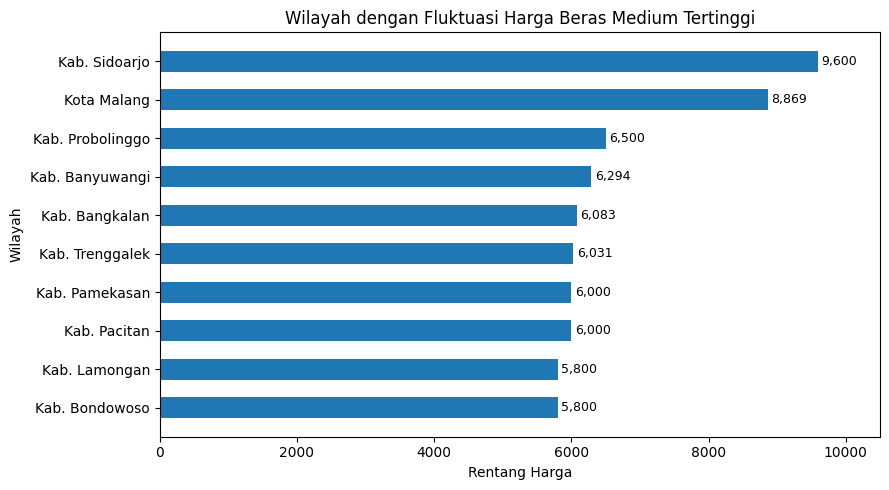

In [457]:
# Menghitung fluktuasi harga per wilayah
fluktuasi_wilayah = (
    data_komoditas
    .groupby('nama_kabupaten_kota')
    .agg(
        harga_minimum=('jumlah', 'min'),
        harga_maksimum=('jumlah', 'max'),
        rata_rata_harga=('jumlah', 'mean'),
        standar_deviasi=('jumlah', 'std')
    )
    .reset_index()
)

# Menghitung rentang harga
fluktuasi_wilayah['rentang_harga'] = (
    fluktuasi_wilayah['harga_maksimum'] - fluktuasi_wilayah['harga_minimum']
)

# Mengambil 10 wilayah paling tidak stabil
top_fluktuasi = (
    fluktuasi_wilayah
    .sort_values('rentang_harga', ascending=False)
    .head(10)
)

# Membuat label wilayah
label_fluktuasi = (
    top_fluktuasi['nama_kabupaten_kota']
    .str.replace('Kabupaten ', 'Kab. ', regex=False)
)

# Membuat visualisasi horizontal bar
plt.figure(figsize=(9, 5))

bars = plt.barh(
    label_fluktuasi,
    top_fluktuasi['rentang_harga'],
    height=0.55
)

plt.title(f'Wilayah dengan Fluktuasi Harga {komoditas_pilihan} Tertinggi')
plt.xlabel('Rentang Harga')
plt.ylabel('Wilayah')
plt.gca().invert_yaxis()

# Menampilkan nilai pada bar
for bar in bars:
    plt.text(
        bar.get_width() + 50,
        bar.get_y() + bar.get_height() / 2,
        f'{bar.get_width():,.0f}',
        va='center',
        fontsize=9
    )

plt.xlim(0, top_fluktuasi['rentang_harga'].max() + 900)
plt.tight_layout()
plt.show()

# Menyimpan hasil utama
wilayah_fluktuasi_tertinggi = top_fluktuasi.iloc[0]['nama_kabupaten_kota']
nilai_fluktuasi_tertinggi = top_fluktuasi.iloc[0]['rentang_harga']

**Insight :**
- Kabupaten Sidoarjo memiliki fluktuasi harga Beras Medium tertinggi, dengan rentang harga sekitar **Rp9.600**.
- Kota Malang berada di posisi kedua dengan rentang harga sekitar **Rp8.869**.
- Kabupaten Probolinggo, Kabupaten Banyuwangi, dan Kabupaten Bangkalan juga memiliki rentang harga yang besar.
- Fluktuasi tinggi berarti harga di wilayah tersebut mengalami perubahan yang lebih besar dibanding wilayah lain.
- Kabupaten Sidoarjo menjadi wilayah yang perlu dipantau lebih serius karena harga Beras Medium di wilayah tersebut paling tidak stabil.

### 5. Why:  Mengapa pemantauan harga pangan berbasis wilayah dan komoditas diperlukan dalam SiPangan selama periode Januari 2020 sampai Mei 2026?

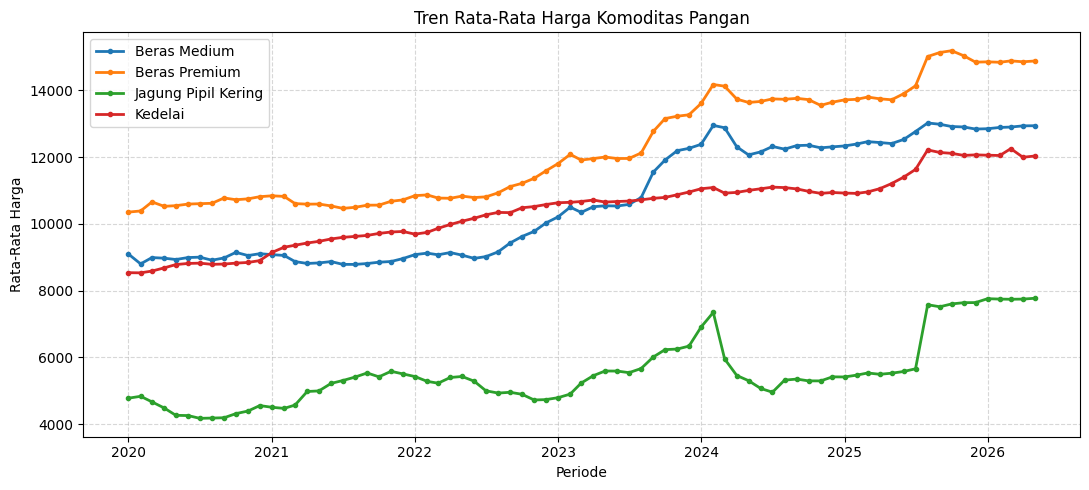

In [458]:
# Menghitung tren rata-rata harga bulanan per komoditas
tren_komoditas = (
    data_analisis
    .groupby(['periode_update', 'kategori'])['jumlah']
    .mean()
    .reset_index()
    .sort_values('periode_update')
)

# Membuat visualisasi tren harga semua komoditas
plt.figure(figsize=(11, 5))

for kategori in tren_komoditas['kategori'].unique():
    data_plot = tren_komoditas[
        tren_komoditas['kategori'] == kategori
    ]

    plt.plot(
        data_plot['periode_update'],
        data_plot['jumlah'],
        marker='o',
        linewidth=2,
        markersize=3,
        label=kategori
    )

plt.title('Tren Rata-Rata Harga Komoditas Pangan')
plt.xlabel('Periode')
plt.ylabel('Rata-Rata Harga')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Insight :**
- Beras Premium konsisten berada pada level harga paling tinggi dibanding komoditas lain.
- Jagung Pipil Kering berada pada level harga paling rendah.
- Beras Medium mengalami kenaikan yang cukup jelas setelah tahun 2022.
- Kedelai memiliki pola harga yang cukup tinggi dan berubah-ubah.
- Setiap komoditas memiliki pola harga yang berbeda dari waktu ke waktu.
- Pemantauan harga perlu dilakukan berdasarkan komoditas, wilayah, dan periode agar perubahan harga pangan dapat terlihat lebih jelas.
- Dashboard SiPangan perlu menampilkan seluruh komoditas, bukan hanya satu komoditas tertentu.

### 6. How:  Bagaimana pola historis harga komoditas yang dipilih dapat membantu masyarakat, pelaku pasar, dan pengelola pangan daerah memperkirakan arah harga pada bulan berikutnya?

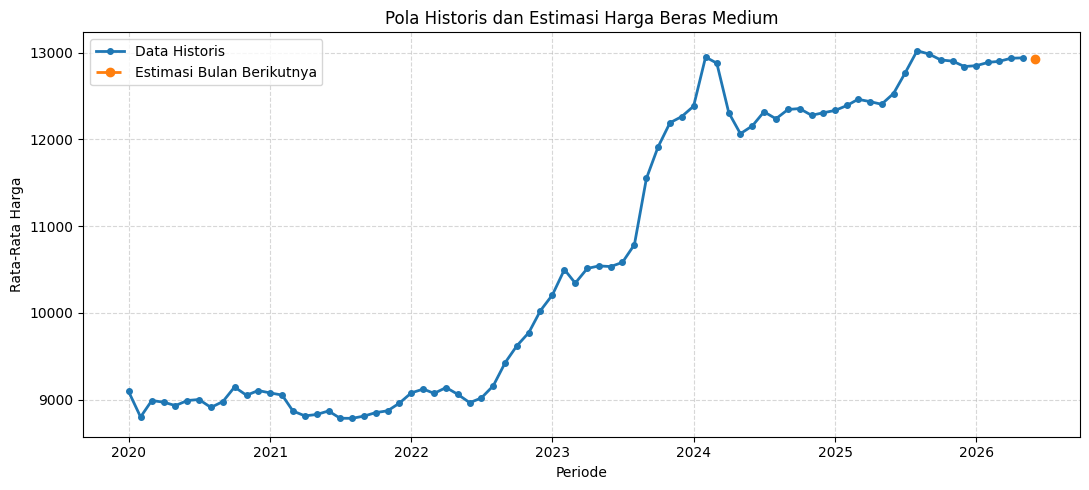

In [459]:
# Mengambil data historis bulanan
data_historis = tren_bulanan_komoditas.copy()

# Estimasi sederhana dari 3 bulan terakhir
harga_terakhir = data_historis['jumlah'].iloc[-1]
estimasi_bulan_berikutnya = data_historis['jumlah'].tail(3).mean()
periode_berikutnya = data_historis['periode_update'].max() + pd.DateOffset(months=1)

data_estimasi = pd.DataFrame({
    'periode_update': [periode_berikutnya],
    'jumlah': [estimasi_bulan_berikutnya]
})

# Membuat visualisasi historis dan estimasi
plt.figure(figsize=(11, 5))

plt.plot(
    data_historis['periode_update'],
    data_historis['jumlah'],
    marker='o',
    linewidth=2,
    markersize=4,
    label='Data Historis'
)

plt.plot(
    data_estimasi['periode_update'],
    data_estimasi['jumlah'],
    marker='o',
    linestyle='--',
    linewidth=2,
    markersize=6,
    label='Estimasi Bulan Berikutnya'
)

plt.title(f'Pola Historis dan Estimasi Harga {komoditas_pilihan}')
plt.xlabel('Periode')
plt.ylabel('Rata-Rata Harga')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Menyimpan hasil utama
arah_harga = 'naik' if estimasi_bulan_berikutnya > harga_terakhir else 'turun atau stabil'

**Insight :**
- Harga Beras Medium meningkat dari kisaran **Rp8.000-an** pada awal periode menjadi sekitar **Rp11.000-an** pada periode akhir.
- Pada periode akhir data, harga berada di level yang relatif tinggi.
- Estimasi bulan berikutnya berada dekat dengan harga bulan terakhir.
- Berdasarkan rata-rata 3 bulan terakhir, arah harga bulan berikutnya cenderung **stabil**.
- Estimasi ini masih bersifat sederhana dan belum menggantikan hasil model forecasting.
- Riwayat harga dapat digunakan sebagai dasar awal untuk pengembangan fitur prediksi harga di SiPangan.

#**Conclusion**

- Dataset harga pangan Jawa Timur berhasil dibersihkan dan disiapkan untuk analisis dengan cakupan 38 wilayah, 4 komoditas, dan periode Januari 2020 sampai Mei 2026.
- Komoditas yang dianalisis adalah Beras Medium, Beras Premium, Jagung Pipil Kering, dan Kedelai.
- Beras Premium memiliki rata-rata harga tertinggi dibanding komoditas lain.
- Kedelai memiliki fluktuasi harga paling besar, sehingga perlu diperhatikan dalam pemantauan harga.
- Untuk komoditas default Beras Medium, Kota Surabaya memiliki rata-rata harga tertinggi.
- Kabupaten Sidoarjo memiliki fluktuasi harga Beras Medium tertinggi.
- Harga Beras Medium mengalami kenaikan cukup kuat setelah tahun 2022 dan tetap berada pada level tinggi hingga 2026.
- Dashboard SiPangan dibutuhkan untuk membantu pemantauan harga pangan berdasarkan komoditas, wilayah, dan periode.
- Pola historis harga dapat digunakan sebagai dasar awal untuk pengembangan fitur prediksi harga pada sistem SiPangan.

#**Dashboard Preparation**

In [460]:
# Membuat folder project dashboard dan folder data
os.makedirs("SiPangan", exist_ok=True)
os.makedirs("SiPangan/data", exist_ok=True)

print("Folder SiPangan dan SiPangan/data berhasil dibuat.")

Folder SiPangan dan SiPangan/data berhasil dibuat.


In [461]:
# Menyimpan data raw BPS ke folder
data_bps.to_csv("SiPangan/data/data_raw_bps.csv", index=False)

print("Data raw BPS berhasil disimpan ke SiPangan/data.")

Data raw BPS berhasil disimpan ke SiPangan/data.


In [462]:
# Menyimpan data gabungan ke folder data
data_gabungan.to_csv("SiPangan/data/data_gabungan.csv", index=False)

print("Data gabungan berhasil disimpan ke SiPangan/data.")

Data gabungan berhasil disimpan ke SiPangan/data.


In [463]:
# Menyimpan data clean ke folder data
data_clean.to_csv("SiPangan/data/data_clean.csv", index=False)

print("Data clean berhasil disimpan ke SiPangan/data.")

Data clean berhasil disimpan ke SiPangan/data.


In [464]:
# Menyimpan data final untuk dashboard
data_final.to_csv("SiPangan/data/data_final.csv", index=False)

print("Data final berhasil disimpan ke SiPangan/data.")

Data final berhasil disimpan ke SiPangan/data.


In [465]:
# Menyimpan data dictionary ke folder data
data_dictionary.to_csv("SiPangan/data/data_dictionary.csv", index=False)

print("Data dictionary berhasil disimpan ke SiPangan/data.")

Data dictionary berhasil disimpan ke SiPangan/data.


In [466]:
%%writefile SiPangan/requirements.txt
streamlit
pandas
numpy
plotly

Overwriting SiPangan/requirements.txt


In [467]:
%%writefile SiPangan/main.py
import streamlit as st
import pandas as pd
import plotly.express as px


# =========================================================
# PAGE CONFIG
# =========================================================
st.set_page_config(
    page_title="SiPangan Analytics",
    layout="wide",
    initial_sidebar_state="collapsed"
)


# =========================================================
# CSS
# =========================================================
st.markdown("""
<style>
.block-container {
    max-width: 1220px;
    padding-top: 1.3rem;
    padding-bottom: 1.5rem;
}

h1 {
    font-size: 1.85rem !important;
    font-weight: 700 !important;
    color: #1f2937;
    margin-bottom: 0.15rem !important;
}

h2, h3 {
    color: #1f2937;
    font-weight: 650 !important;
}

p, label, span {
    color: #374151;
}

[data-testid="stMetric"] {
    background-color: #ffffff;
    border: 1px solid #e5e7eb;
    padding: 0.85rem 1rem;
    border-radius: 14px;
}

[data-testid="stMetricLabel"] {
    font-size: 0.78rem !important;
    color: #6b7280 !important;
}

[data-testid="stMetricValue"] {
    font-size: 1.18rem !important;
    font-weight: 700 !important;
    color: #111827 !important;
}

.stTabs [data-baseweb="tab-list"] {
    gap: 0.5rem;
    border-bottom: 1px solid #e5e7eb;
}

.stTabs [data-baseweb="tab"] {
    height: 40px;
    padding-left: 0.9rem;
    padding-right: 0.9rem;
    font-weight: 600;
}

.stTabs [aria-selected="true"] {
    color: #2563eb !important;
}

div[data-testid="stVerticalBlock"] {
    gap: 0.65rem;
}

.small-caption {
    font-size: 0.92rem;
    color: #6b7280;
    margin-bottom: 0.7rem;
}

.insight-box {
    background-color: #f8fafc;
    border: 1px solid #e5e7eb;
    border-left: 4px solid #2563eb;
    padding: 0.85rem 1rem;
    border-radius: 12px;
    font-size: 0.92rem;
    color: #1f2937;
    line-height: 1.55;
}

hr {
    margin-top: 0.3rem;
    margin-bottom: 0.7rem;
}
</style>
""", unsafe_allow_html=True)


# =========================================================
# LOAD DATA
# =========================================================
@st.cache_data
def load_data():
    data = pd.read_csv("data/data_final.csv")

    data["periode_update"] = pd.to_datetime(data["periode_update"])
    data["tahun"] = data["periode_update"].dt.year
    data["bulan"] = data["periode_update"].dt.month
    data["tahun_bulan"] = data["periode_update"].dt.to_period("M").astype(str)

    if "series_id" not in data.columns:
        data["series_id"] = (
            data["nama_kabupaten_kota"].astype(str)
            + " | "
            + data["kategori"].astype(str)
        )

    return data


data = load_data()

daftar_komoditas = sorted(data["kategori"].unique())
daftar_wilayah = sorted(data["nama_kabupaten_kota"].unique())
tahun_min = int(data["tahun"].min())
tahun_max = int(data["tahun"].max())

plotly_config = {
    "displayModeBar": False,
    "responsive": True
}

COLORS = ["#2563eb", "#60a5fa", "#ef4444", "#0f766e", "#f97316"]


# =========================================================
# HELPER
# =========================================================
def rupiah(nilai):
    if pd.isna(nilai):
        return "Rp0"
    return f"Rp{int(round(nilai, 0)):,}".replace(",", ".")


def filter_tahun(df, tahun_range):
    return df[df["tahun"].between(tahun_range[0], tahun_range[1])].copy()


def clean_layout(fig, height=335, legend=True):
    fig.update_layout(
        template="plotly_white",
        height=height,
        margin=dict(l=25, r=25, t=50, b=60),
        font=dict(size=12, color="#374151"),
        title_font=dict(size=16, color="#1f2937"),
        plot_bgcolor="white",
        paper_bgcolor="white",
        legend_title_text=""
    )

    if legend:
        fig.update_layout(
            legend=dict(
                orientation="h",
                yanchor="top",
                y=-0.18,
                xanchor="center",
                x=0.5
            )
        )
    else:
        fig.update_layout(showlegend=False)

    fig.update_xaxes(showgrid=False, zeroline=False)
    fig.update_yaxes(gridcolor="#e5e7eb", zeroline=False)
    return fig


def make_line_chart(df, x, y, title, color=None, height=350):
    fig = px.line(
        df,
        x=x,
        y=y,
        color=color,
        markers=True,
        title=title,
        color_discrete_sequence=COLORS
    )

    fig.update_traces(line=dict(width=2.6), marker=dict(size=5))
    fig = clean_layout(fig, height=height, legend=color is not None)
    fig.update_xaxes(title="")
    fig.update_yaxes(title="Harga")

    return fig


def make_bar_chart(df, x, y, title, color="#2563eb", height=360):
    fig = px.bar(
        df,
        x=x,
        y=y,
        orientation="h",
        text=x,
        title=title
    )

    fig.update_traces(
        marker_color=color,
        texttemplate="%{text:,.0f}",
        textposition="outside",
        cliponaxis=False
    )

    fig = clean_layout(fig, height=height, legend=False)
    fig.update_layout(margin=dict(l=25, r=110, t=50, b=30))
    fig.update_xaxes(title="")
    fig.update_yaxes(title="", autorange="reversed")

    return fig


def make_scatter_chart(df, title):
    fig = px.scatter(
        df,
        x="rata_rata_harga",
        y="fluktuasi_harga",
        size="fluktuasi_harga",
        text="kategori",
        hover_name="kategori",
        hover_data={
            "rata_rata_harga": ":,.0f",
            "fluktuasi_harga": ":,.0f"
        },
        title=title,
        color_discrete_sequence=["#2563eb"]
    )

    fig.update_traces(
        textposition="top center",
        textfont=dict(size=11),
        marker=dict(opacity=0.82),
        cliponaxis=False
    )

    fig = clean_layout(fig, height=360, legend=False)
    fig.update_layout(margin=dict(l=35, r=45, t=55, b=55))

    x_min = df["rata_rata_harga"].min()
    x_max = df["rata_rata_harga"].max()
    y_min = df["fluktuasi_harga"].min()
    y_max = df["fluktuasi_harga"].max()

    x_pad = (x_max - x_min) * 0.18 if x_max != x_min else x_max * 0.1
    y_pad = (y_max - y_min) * 0.22 if y_max != y_min else y_max * 0.1

    fig.update_xaxes(
        title="Rata-rata Harga",
        range=[x_min - x_pad, x_max + x_pad]
    )
    fig.update_yaxes(
        title="Fluktuasi Harga",
        range=[max(0, y_min - y_pad), y_max + y_pad]
    )

    return fig


# =========================================================
# HEADER
# =========================================================
st.title("SiPangan Analytics")
st.markdown(
    '<div class="small-caption">Analisis interaktif harga pangan Jawa Timur untuk membaca tren komoditas membandingkan wilayah dan memperkirakan arah harga.</div>',
    unsafe_allow_html=True
)


# =========================================================
# TABS
# =========================================================
tab_overview, tab_wilayah, tab_tren, tab_data = st.tabs([
    "Overview",
    "Perbandingan Wilayah",
    "Tren & Estimasi",
    "Data"
])


# =========================================================
# TAB 1: OVERVIEW
# =========================================================
with tab_overview:
    st.subheader("Overview Harga Pangan")

    tahun_overview = st.slider(
        "Rentang Tahun",
        min_value=tahun_min,
        max_value=tahun_max,
        value=(tahun_min, tahun_max),
        key="tahun_overview"
    )

    overview_data = filter_tahun(data, tahun_overview)

    periode_awal = overview_data["tahun_bulan"].min()
    periode_akhir = overview_data["tahun_bulan"].max()

    k1, k2, k3, k4, k5 = st.columns(5)

    k1.metric("Jumlah Data", f"{len(overview_data):,}")
    k2.metric("Wilayah", overview_data["nama_kabupaten_kota"].nunique())
    k3.metric("Komoditas", overview_data["kategori"].nunique())
    k4.metric("Rata-rata Harga", rupiah(overview_data["jumlah"].mean()))
    k5.metric("Periode", f"{periode_awal} - {periode_akhir}")

    ringkasan_komoditas = (
        overview_data
        .groupby("kategori", as_index=False)
        .agg(
            rata_rata_harga=("jumlah", "mean"),
            fluktuasi_harga=("jumlah", "std")
        )
    )

    tren_semua = (
        overview_data
        .groupby(["periode_update", "kategori"], as_index=False)["jumlah"]
        .mean()
        .sort_values("periode_update")
    )

    tren_semua["rata_rata_3_bulan"] = (
        tren_semua
        .groupby("kategori")["jumlah"]
        .transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    )

    c1, c2 = st.columns(2)

    with c1:
        fig_prioritas = make_scatter_chart(
            ringkasan_komoditas,
            title="Prioritas Pemantauan Komoditas"
        )
        st.plotly_chart(fig_prioritas, use_container_width=True, config=plotly_config)

    with c2:
        fig_tren = make_line_chart(
            tren_semua,
            x="periode_update",
            y="rata_rata_3_bulan",
            color="kategori",
            title="Tren Rata-rata Harga Semua Komoditas",
            height=360
        )
        st.plotly_chart(fig_tren, use_container_width=True, config=plotly_config)

    komoditas_termahal = ringkasan_komoditas.sort_values("rata_rata_harga", ascending=False).iloc[0]
    komoditas_fluktuatif = ringkasan_komoditas.sort_values("fluktuasi_harga", ascending=False).iloc[0]

    st.markdown(
        f"""
        <div class="insight-box">
        <b>Ringkasan:</b> Pada periode {tahun_overview[0]}–{tahun_overview[1]},
        komoditas dengan rata-rata harga tertinggi adalah <b>{komoditas_termahal['kategori']}</b>
        sekitar <b>{rupiah(komoditas_termahal['rata_rata_harga'])}</b>.
        Komoditas dengan fluktuasi harga tertinggi adalah <b>{komoditas_fluktuatif['kategori']}</b>
        dengan deviasi sekitar <b>{rupiah(komoditas_fluktuatif['fluktuasi_harga'])}</b>.
        </div>
        """,
        unsafe_allow_html=True
    )


# =========================================================
# TAB 2: PERBANDINGAN WILAYAH
# =========================================================
with tab_wilayah:
    st.subheader("Perbandingan Wilayah")
    st.caption("Bagian ini membandingkan seluruh wilayah sehingga tidak membutuhkan filter wilayah tertentu.")

    f1, f2, f3 = st.columns([1.05, 1.05, 0.9])

    with f1:
        komoditas_wilayah = st.selectbox(
            "Komoditas",
            daftar_komoditas,
            index=daftar_komoditas.index("Beras Medium") if "Beras Medium" in daftar_komoditas else 0,
            key="komoditas_wilayah"
        )

    with f2:
        tahun_wilayah = st.slider(
            "Rentang Tahun",
            min_value=tahun_min,
            max_value=tahun_max,
            value=(tahun_min, tahun_max),
            key="tahun_wilayah"
        )

    with f3:
        top_n = st.slider(
            "Jumlah Wilayah",
            min_value=5,
            max_value=15,
            value=10,
            key="top_n"
        )

    data_wilayah = data[
        (data["kategori"] == komoditas_wilayah)
        & (data["tahun"].between(tahun_wilayah[0], tahun_wilayah[1]))
    ].copy()

    rata_wilayah = (
        data_wilayah
        .groupby("nama_kabupaten_kota", as_index=False)["jumlah"]
        .mean()
        .sort_values("jumlah", ascending=False)
        .head(top_n)
        .sort_values("jumlah", ascending=True)
    )

    fluktuasi_wilayah = (
        data_wilayah
        .groupby("nama_kabupaten_kota", as_index=False)
        .agg(
            harga_minimum=("jumlah", "min"),
            harga_maksimum=("jumlah", "max")
        )
    )

    fluktuasi_wilayah["rentang_harga"] = (
        fluktuasi_wilayah["harga_maksimum"] - fluktuasi_wilayah["harga_minimum"]
    )

    fluktuasi_wilayah = (
        fluktuasi_wilayah
        .sort_values("rentang_harga", ascending=False)
        .head(top_n)
        .sort_values("rentang_harga", ascending=True)
    )

    c1, c2 = st.columns(2)

    with c1:
        fig_rata_wilayah = make_bar_chart(
            rata_wilayah,
            x="jumlah",
            y="nama_kabupaten_kota",
            title="Wilayah dengan Harga Tertinggi",
            color="#2563eb",
            height=370
        )
        st.plotly_chart(fig_rata_wilayah, use_container_width=True, config=plotly_config)

    with c2:
        fig_fluktuasi_wilayah = make_bar_chart(
            fluktuasi_wilayah,
            x="rentang_harga",
            y="nama_kabupaten_kota",
            title="Wilayah dengan Fluktuasi Tertinggi",
            color="#0f766e",
            height=370
        )
        st.plotly_chart(fig_fluktuasi_wilayah, use_container_width=True, config=plotly_config)

    if not rata_wilayah.empty and not fluktuasi_wilayah.empty:
        wilayah_tertinggi = rata_wilayah.sort_values("jumlah", ascending=False).iloc[0]
        wilayah_fluktuatif = fluktuasi_wilayah.sort_values("rentang_harga", ascending=False).iloc[0]

        st.markdown(
            f"""
            <div class="insight-box">
            <b>Ringkasan:</b> Untuk komoditas <b>{komoditas_wilayah}</b> pada periode {tahun_wilayah[0]}–{tahun_wilayah[1]},
            wilayah dengan rata-rata harga tertinggi adalah <b>{wilayah_tertinggi['nama_kabupaten_kota']}</b>
            sekitar <b>{rupiah(wilayah_tertinggi['jumlah'])}</b>. Wilayah dengan fluktuasi tertinggi adalah
            <b>{wilayah_fluktuatif['nama_kabupaten_kota']}</b> dengan rentang harga sekitar
            <b>{rupiah(wilayah_fluktuatif['rentang_harga'])}</b>.
            </div>
            """,
            unsafe_allow_html=True
        )


# =========================================================
# TAB 3: TREN & ESTIMASI
# =========================================================
with tab_tren:
    st.subheader("Tren & Estimasi Harga")

    f1, f2, f3 = st.columns([1.05, 1.05, 1.1])

    with f1:
        komoditas_tren = st.selectbox(
            "Komoditas",
            daftar_komoditas,
            index=daftar_komoditas.index("Beras Medium") if "Beras Medium" in daftar_komoditas else 0,
            key="komoditas_tren"
        )

    with f2:
        wilayah_tren = st.selectbox(
            "Wilayah",
            daftar_wilayah,
            key="wilayah_tren"
        )

    with f3:
        tahun_tren = st.slider(
            "Rentang Tahun",
            min_value=tahun_min,
            max_value=tahun_max,
            value=(tahun_min, tahun_max),
            key="tahun_tren"
        )

    data_tren = data[
        (data["kategori"] == komoditas_tren)
        & (data["nama_kabupaten_kota"] == wilayah_tren)
        & (data["tahun"].between(tahun_tren[0], tahun_tren[1]))
    ].copy().sort_values("periode_update")

    if data_tren.empty:
        st.warning("Data tidak tersedia untuk filter yang dipilih.")
    else:
        harga_terakhir = data_tren["jumlah"].iloc[-1]
        estimasi = data_tren["jumlah"].tail(3).mean()
        selisih = estimasi - harga_terakhir

        if selisih > 0:
            arah = "Naik"
        elif selisih < 0:
            arah = "Turun"
        else:
            arah = "Stabil"

        c1, c2 = st.columns([2.2, 1])

        with c1:
            fig_tren = make_line_chart(
                data_tren,
                x="periode_update",
                y="jumlah",
                color=None,
                title=f"Tren Harga {komoditas_tren} di {wilayah_tren}",
                height=380
            )
            fig_tren.update_traces(line=dict(color="#2563eb", width=2.8))
            st.plotly_chart(fig_tren, use_container_width=True, config=plotly_config)

        with c2:
            st.metric("Harga Terakhir", rupiah(harga_terakhir))
            st.metric("Estimasi Bulan Berikutnya", rupiah(estimasi), delta=rupiah(selisih))
            st.metric("Arah Harga", arah)

        st.markdown(
            f"""
            <div class="insight-box">
            <b>Ringkasan:</b> Pada periode {tahun_tren[0]}–{tahun_tren[1]}, harga <b>{komoditas_tren}</b>
            di <b>{wilayah_tren}</b> berubah dari sekitar <b>{rupiah(data_tren['jumlah'].iloc[0])}</b>
            menjadi <b>{rupiah(data_tren['jumlah'].iloc[-1])}</b>. Estimasi bulan berikutnya sekitar
            <b>{rupiah(estimasi)}</b> dengan arah harga <b>{arah.lower()}</b>.
            </div>
            """,
            unsafe_allow_html=True
        )


# =========================================================
# TAB 4: DATA
# =========================================================
with tab_data:
    st.subheader("Data Hasil Filter")

    f1, f2, f3 = st.columns([1.05, 1.05, 1.1])

    with f1:
        komoditas_data = st.selectbox(
            "Komoditas",
            daftar_komoditas,
            key="komoditas_data"
        )

    with f2:
        wilayah_data = st.selectbox(
            "Wilayah",
            daftar_wilayah,
            key="wilayah_data"
        )

    with f3:
        tahun_data = st.slider(
            "Rentang Tahun",
            min_value=tahun_min,
            max_value=tahun_max,
            value=(tahun_min, tahun_max),
            key="tahun_data"
        )

    data_tabel = data[
        (data["kategori"] == komoditas_data)
        & (data["nama_kabupaten_kota"] == wilayah_data)
        & (data["tahun"].between(tahun_data[0], tahun_data[1]))
    ].copy().sort_values("periode_update", ascending=False)

    kolom_tampil = [
        "series_id",
        "nama_kabupaten_kota",
        "periode_update",
        "kategori",
        "jumlah",
        "tahun",
        "tahun_bulan"
    ]

    kolom_tampil = [kolom for kolom in kolom_tampil if kolom in data_tabel.columns]

    st.dataframe(
        data_tabel[kolom_tampil],
        use_container_width=True,
        hide_index=True,
        height=390
    )

    csv = data_tabel[kolom_tampil].to_csv(index=False).encode("utf-8")

    st.download_button(
        label="Download Data Hasil Filter",
        data=csv,
        file_name="data_hasil_filter_sipangan.csv",
        mime="text/csv"
    )

Overwriting SiPangan/main.py


In [468]:
%%writefile SiPangan/README.md
# SiPangan Analytics
SiPangan Analytics adalah dashboard interaktif berbasis Streamlit untuk menganalisis harga pangan di Provinsi Jawa Timur. Dashboard ini menampilkan ringkasan harga pangan, perbandingan antarwilayah, tren historis, estimasi sederhana harga bulan berikutnya, serta data hasil filter yang dapat diunduh.
---

## Tujuan Project
Project ini dibuat untuk menyiapkan dan menganalisis data harga pangan Jawa Timur agar lebih mudah dipahami melalui dashboard interaktif.
Tujuan utama project ini adalah:
- Menyiapkan data harga pangan Jawa Timur agar siap dianalisis.
- Menggabungkan data dari Kaggle dan data tambahan BPS.
- Menganalisis harga pangan berdasarkan komoditas, wilayah, dan periode.
- Menampilkan insight utama melalui visualisasi dan dashboard interaktif.
- Menyediakan dataset final yang dapat digunakan untuk dashboard dan analisis lanjutan.

---

## Sumber Data
Data yang digunakan berasal dari dua sumber utama:
1. Kaggle - Harga Pertanian Jawa Timur
   https://www.kaggle.com/datasets/rakafal/harga-pertanian-jawa-timur
2. Data tambahan BPS
   Data tambahan ini digunakan untuk melengkapi periode data terbaru.
Dataset final yang digunakan oleh dashboard berada di:
```text
data/data_final.csv
```
Data BPS juga sudah disimpan di folder `data`, sehingga project dapat dijalankan tanpa perlu mengakses Google Drive pribadi.
---

## Struktur Folder
Struktur folder project:
```text
SiPangan/
├── main.py
├── requirements.txt
├── README.md
├── SiPangan.ipynb
└── data/
    ├── data_raw_bps.csv
    ├── data_gabungan.csv
    ├── data_clean.csv
    ├── data_final.csv
    └── data_dictionary.csv
```
File minimal yang wajib ada agar dashboard dapat berjalan:
```text
main.py
requirements.txt
data/data_final.csv
```

---
## Keterangan File
`main.py`
File utama untuk menjalankan dashboard Streamlit.
`requirements.txt`
Daftar library yang dibutuhkan untuk menjalankan dashboard.
`SiPangan.ipynb`
Notebook yang berisi proses analisis data dari awal sampai akhir.
`data/data_final.csv`
Dataset final yang digunakan oleh dashboard.
`data/data_dictionary.csv`
Penjelasan kolom pada dataset final.
`data/data_clean.csv`
Data yang sudah melalui proses cleaning.
`data/data_gabungan.csv`
Data gabungan dari Kaggle dan BPS.
`data/data_raw_bps.csv`
Data mentah tambahan dari BPS.
---

## Environment
Dashboard ini membutuhkan Python dan beberapa library berikut:
```text
streamlit
pandas
numpy
plotly
```
Semua library tersebut sudah ditulis di dalam file `requirements.txt`.
---

## Cara Menjalankan Dashboard
### 1. Clone atau download repository
Clone repository:
```bash
git clone <link-repository>
```
Masuk ke folder project:
```bash
cd SiPangan
```
Jika folder `SiPangan` berada di dalam folder repository lain, masuk ke folder sesuai lokasinya.
Contoh:
```bash
cd nama-repo/SiPangan
```

---
### 2. Install library
Jalankan perintah berikut di terminal atau CMD:
```bash
pip install -r requirements.txt
```
Jika `pip` tidak terbaca, gunakan:
```bash
python -m pip install -r requirements.txt
```

---
### 3. Jalankan dashboard
Jalankan:
```bash
streamlit run main.py
```
Jika `streamlit` tidak terbaca, gunakan:
```bash
python -m streamlit run main.py
```
Setelah berhasil, dashboard akan terbuka di browser melalui alamat:
```text
http://localhost:8501
```

---
## Fitur Dashboard
### Overview
Menampilkan ringkasan umum harga pangan, jumlah data, jumlah wilayah, jumlah komoditas, rata-rata harga, periode data, prioritas pemantauan komoditas, dan tren harga semua komoditas.

### Perbandingan Wilayah
Menampilkan perbandingan seluruh wilayah berdasarkan komoditas yang dipilih. Bagian ini menunjukkan wilayah dengan rata-rata harga tertinggi dan wilayah dengan fluktuasi harga tertinggi.

### Tren & Estimasi
Menampilkan tren harga berdasarkan komoditas dan wilayah tertentu. Estimasi sederhana harga bulan berikutnya dihitung menggunakan rata-rata tiga bulan terakhir.

### Data
Menampilkan data hasil filter berdasarkan komoditas, wilayah, dan rentang tahun. Data hasil filter juga dapat diunduh dalam format CSV.
---

## Ringkasan Proses Analisis
Proses analisis dilakukan dalam notebook `SiPangan.ipynb`.
Tahapan analisis yang dilakukan:

1. Business Understanding
   Menentukan tujuan project dan kebutuhan analisis.
2. Data Gathering
   Mengambil data dari Kaggle dan data tambahan BPS.
3. Assessing Data
   Mengecek struktur data, periode, kategori, wilayah, missing value, nilai nol, dan duplikasi.
4. Cleaning Data
   Merapikan data agar lebih konsisten dan siap dianalisis.
5. Feature Engineering
   Menambahkan fitur pendukung seperti `tahun`, `bulan`, `tahun_bulan`, dan `series_id`.
6. Data Dictionary
   Membuat penjelasan kolom dataset final.
7. EDA dan Visualisasi
   Menganalisis pola harga berdasarkan waktu, komoditas, dan wilayah.
8. Conclusion
   Merangkum hasil utama dari analisis.
9. Dashboard Preparation
   Menyiapkan file dashboard, requirements, dan dataset final.
10. A/B Testing Dashboard
   Membandingkan dashboard versi awal dan versi final berdasarkan kriteria penilaian.
---

## Catatan Penting
Agar dashboard tidak error, pastikan:
- File `data_final.csv` berada di folder `data`.
- File `requirements.txt` tidak dihapus.
- File CSV tidak dipindahkan keluar dari folder `data`.
- Nama file `data_final.csv` tidak diubah tanpa menyesuaikan path di `main.py`.

Di dalam `main.py`, dataset dibaca dari:
```python
pd.read_csv("data/data_final.csv")
```
Data raw BPS sudah disimpan di folder `data`, sehingga pengguna lain tidak perlu mengakses Google Drive pribadi.
---

## Author

Project ini dikembangkan sebagai bagian dari analisis data harga pangan Jawa Timur.

Overwriting SiPangan/README.md


In [469]:
!zip -r SiPangan.zip SiPangan

updating: SiPangan/ (stored 0%)
updating: SiPangan/main.py (deflated 75%)
updating: SiPangan/requirements.txt (stored 0%)
updating: SiPangan/data/ (stored 0%)
updating: SiPangan/data/data_raw_bps.csv (deflated 91%)
updating: SiPangan/data/data_gabungan.csv (deflated 91%)
updating: SiPangan/data/data_final.csv (deflated 92%)
updating: SiPangan/data/data_clean.csv (deflated 89%)
updating: SiPangan/README.md (deflated 63%)
updating: SiPangan/data/data_dictionary.csv (deflated 37%)


# **A/B Testing**

In [470]:
# Rubrik A/B testing dashboard menggunakan Python
ab_testing_dashboard = pd.DataFrame({
    'aspek_evaluasi': [
        'Struktur tampilan',
        'Interaktivitas grafik',
        'Kebutuhan scroll',
        'Kelengkapan filter',
        'Ringkasan KPI',
        'Insight otomatis',
        'Fitur download data',
        'Kesesuaian dashboard interaktif'
    ],
    'bobot': [
        0.15,
        0.20,
        0.10,
        0.15,
        0.10,
        0.10,
        0.10,
        0.10
    ],
    'skor_versi_a': [
        2,  # tampilan memanjang
        2,  # grafik statis
        2,  # scroll tinggi
        3,  # filter dasar
        1,  # KPI belum tersedia
        1,  # insight otomatis belum tersedia
        1,  # download belum tersedia
        2   # cukup, tapi belum optimal
    ],
    'skor_versi_b': [
        5,  # menggunakan tab
        5,  # grafik Plotly interaktif
        4,  # scroll lebih rendah
        5,  # filter lengkap
        5,  # KPI tersedia
        5,  # insight otomatis tersedia
        5,  # download tersedia
        5   # lebih sesuai
    ]
})

display(ab_testing_dashboard)

,aspek_evaluasi,bobot,skor_versi_a,skor_versi_b
0,Struktur tampilan,0.15,2,5
1,Interaktivitas grafik,0.20,2,5
2,Kebutuhan scroll,0.10,2,4
3,Kelengkapan filter,0.15,3,5
4,Ringkasan KPI,0.10,1,5
5,Insight otomatis,0.10,1,5
6,Fitur download data,0.10,1,5
7,Kesesuaian dashboard interaktif,0.10,2,5


In [471]:
# Menghitung skor berbobot
ab_testing_dashboard['nilai_versi_a'] = (
    ab_testing_dashboard['bobot'] * ab_testing_dashboard['skor_versi_a']
)

ab_testing_dashboard['nilai_versi_b'] = (
    ab_testing_dashboard['bobot'] * ab_testing_dashboard['skor_versi_b']
)

skor_akhir_a = ab_testing_dashboard['nilai_versi_a'].sum()
skor_akhir_b = ab_testing_dashboard['nilai_versi_b'].sum()

print("Skor akhir Versi A:", round(skor_akhir_a, 2))
print("Skor akhir Versi B:", round(skor_akhir_b, 2))

if skor_akhir_b > skor_akhir_a:
    print("Dashboard final yang dipilih adalah Versi B.")
else:
    print("Dashboard final yang dipilih adalah Versi A.")

Skor akhir Versi A: 1.85
Skor akhir Versi B: 4.9
Dashboard final yang dipilih adalah Versi B.


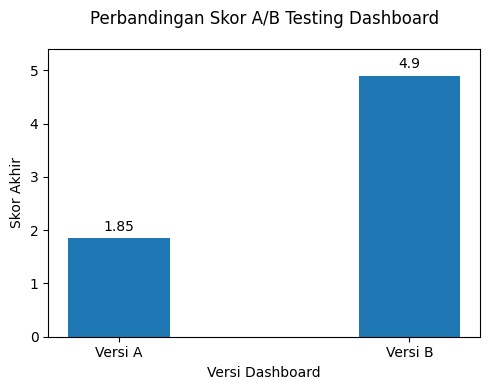

In [472]:
# Visualisasi skor akhir A/B testing
hasil_ab_testing = pd.DataFrame({
    'versi_dashboard': ['Versi A', 'Versi B'],
    'skor_akhir': [skor_akhir_a, skor_akhir_b]
})

plt.figure(figsize=(5, 4))

bars = plt.bar(
    hasil_ab_testing['versi_dashboard'],
    hasil_ab_testing['skor_akhir'],
    width=0.35
)

plt.title('Perbandingan Skor A/B Testing Dashboard', pad=18)
plt.xlabel('Versi Dashboard')
plt.ylabel('Skor Akhir')
plt.ylim(0, 5.4)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.08,
        round(bar.get_height(), 2),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

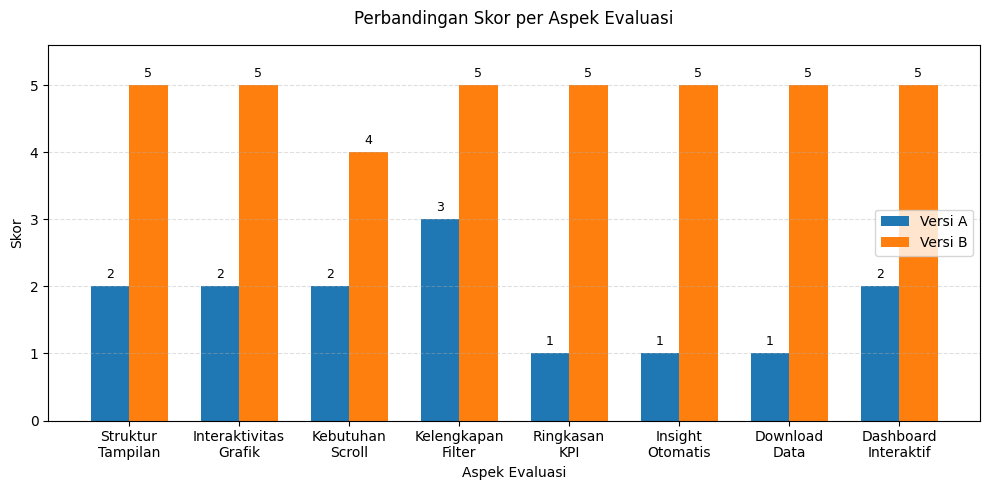

In [473]:
# Label aspek dibuat 2 baris agar rapi
label_aspek = [
    'Struktur\nTampilan',
    'Interaktivitas\nGrafik',
    'Kebutuhan\nScroll',
    'Kelengkapan\nFilter',
    'Ringkasan\nKPI',
    'Insight\nOtomatis',
    'Download\nData',
    'Dashboard\nInteraktif'
]

x = np.arange(len(ab_testing_dashboard))
lebar_bar = 0.35

plt.figure(figsize=(10, 5))

bars_a = plt.bar(
    x - lebar_bar / 2,
    ab_testing_dashboard['skor_versi_a'],
    width=lebar_bar,
    label='Versi A'
)

bars_b = plt.bar(
    x + lebar_bar / 2,
    ab_testing_dashboard['skor_versi_b'],
    width=lebar_bar,
    label='Versi B'
)

plt.title('Perbandingan Skor per Aspek Evaluasi', pad=15)
plt.xlabel('Aspek Evaluasi')
plt.ylabel('Skor')
plt.xticks(x, label_aspek, rotation=0, ha='center')
plt.ylim(0, 5.6)
plt.legend()

# Menampilkan nilai skor di atas bar Versi A
for bar in bars_a:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.08,
        int(bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

# Menampilkan nilai skor di atas bar Versi B
for bar in bars_b:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.08,
        int(bar.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Insight:**
- A/B testing dilakukan dengan membandingkan dashboard Versi A dan Versi B berdasarkan kriteria penilaian dari kebutuhan proyek dashboard.
- Kriteria penilaian meliputi struktur tampilan, interaktivitas grafik, kebutuhan scroll, kelengkapan filter, KPI, insight otomatis, fitur download data, dan kesesuaian sebagai dashboard interaktif.
- Skor 1–5 diberikan berdasarkan kelengkapan dan kualitas fitur pada masing-masing versi dashboard.
- Versi A memiliki keterbatasan karena tampilannya masih memanjang, interaktivitas terbatas, KPI belum jelas, insight otomatis belum tersedia, dan belum memiliki fitur download data.
- Versi B memiliki skor lebih tinggi karena sudah menggunakan tab, grafik Plotly interaktif, filter sesuai kebutuhan tiap tab, KPI, insight otomatis, dan download data.
- Hasil skor berbobot menunjukkan bahwa Versi B lebih sesuai untuk digunakan sebagai dashboard final SiPangan.
- Evaluasi ini bersifat berbasis fitur, bukan uji statistik pengguna karena belum menggunakan data responden.